# Exploring NetCDF Files

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import netCDF4
import nc_time_axis

#### Minor Cleaning

In [8]:
ds=xr.open_dataset("/projects/dagr5998/icepack-dirs/runs/arctic_mdf_test/history/icepack.h.19750101.nc")
ds=ds.sel(ni=3) # We care about the full ITD ice simulation, other ones aren't necessary

## Relevant Variable Exploration

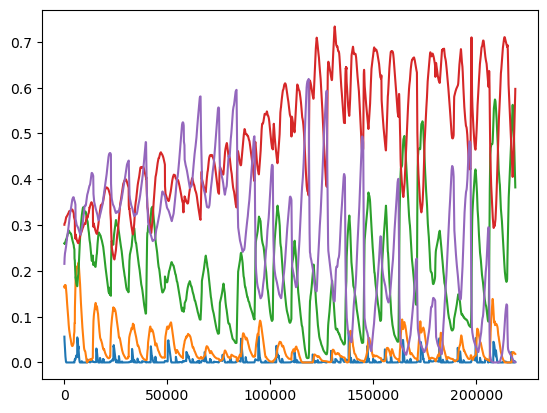

In [3]:
plt.plot(ds["aicen"])

### Area and Volume of Snow and Ice

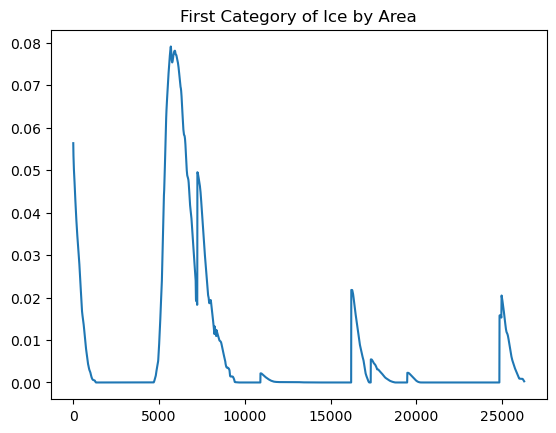

In [21]:
plt.plot(ds["aicen"].sel(ncat=1))
plt.title("First Category of Ice by Area")
plt.show()

Note that for practice runs the number of ice categories has been reduced to 2 to save storage space.

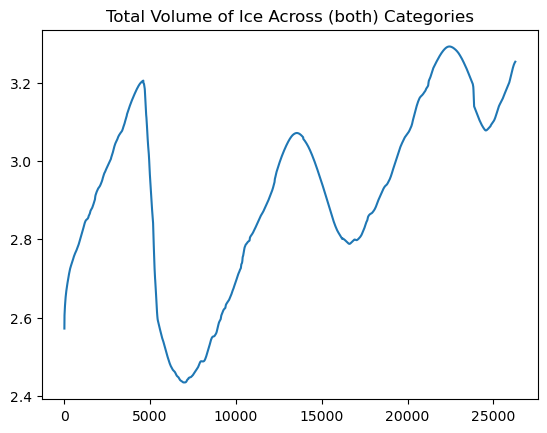

In [22]:
plt.plot(ds["vice"])
plt.title("Total Volume of Ice Across (both) Categories")
plt.show()

Note that aice, vice, vsno, are all redundant and can be derived from aicen, vicen, and vsnon

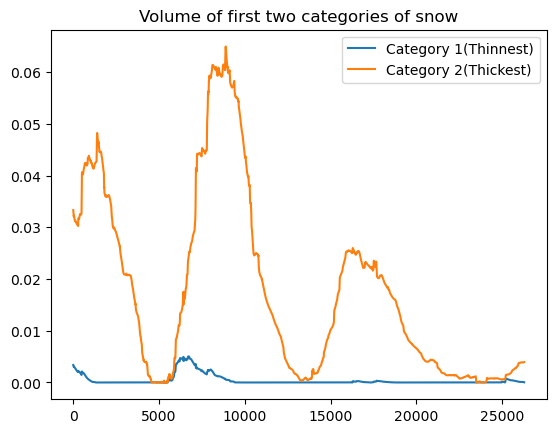

In [30]:
plt.plot(ds["vsnon"].sel(ncat=1), label="Category 1(Thinnest)")
plt.plot(ds["vsnon"].sel(ncat=2), label="Category 2(Thickest)")
plt.legend()
plt.title("Volume of first two categories of snow")
plt.show()

Note that in the default indexing, category 1 is the thinnest for snow/ice and it gets progressively thicker.

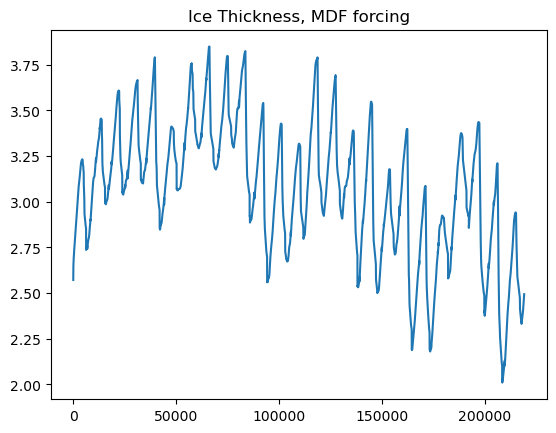

In [9]:
plt.plot(ds["vice"]/ds["aice"])
plt.title("Ice Thickness, MDF forcing 1975-2000")
plt.show()

In [8]:
ds

<xarray.Dataset> Size: 53MB
Dimensions:        (ncat: 5, ntrcr: 25, time: 26280)
Coordinates:
    ni             int32 4B 3
  * ncat           (ncat) int32 20B 1 2 3 4 5
  * ntrcr          (ntrcr) int32 100B 1 2 3 4 5 6 7 8 ... 19 20 21 22 23 24 25
  * time           (time) float64 210kB 0.04167 0.08333 ... 1.095e+03 1.095e+03
Data variables: (12/58)
    timestep       (time) int32 105kB ...
    date           (time) float64 210kB ...
    aice           (time) float64 210kB ...
    vice           (time) float64 210kB 2.572 2.598 2.599 ... 3.254 3.254 3.254
    vsno           (time) float64 210kB ...
    uvel           (time) float64 210kB ...
    ...             ...
    dpnd_exponn    (time, ncat) float64 1MB ...
    dpnd_freebdn   (time, ncat) float64 1MB ...
    dpnd_initialn  (time, ncat) float64 1MB ...
    dpnd_dlidn     (time, ncat) float64 1MB ...
    trcr           (time, ntrcr) float64 5MB ...
    trcrn          (time, ncat, ntrcr) float64 26MB ...

### Other Variables

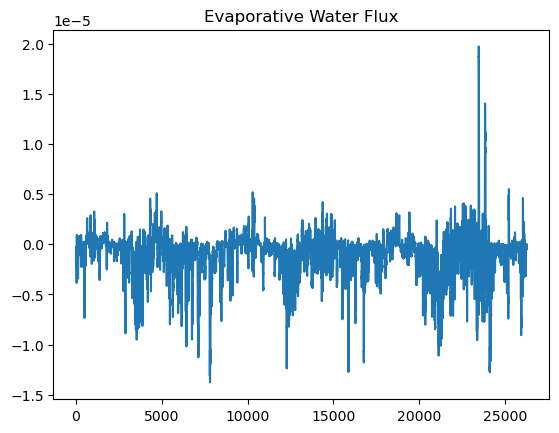

In [9]:
plt.plot(ds["evap"])
plt.title("Evaporative Water Flux")
plt.show()

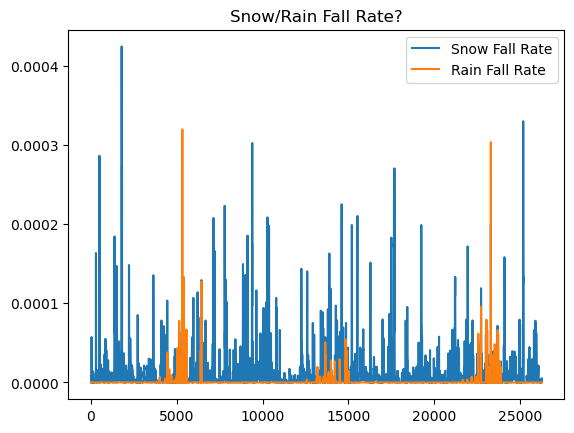

In [10]:
plt.plot(ds["fsnow"], label = "Snow Fall Rate")
plt.plot(ds["frain"], label = "Rain Fall Rate")
plt.title("Snow/Rain Fall Rate?")
plt.legend()
plt.show()

| Variable | Definition |
|---|---|
| frazil | Frazil ice growth  |
| fswabs | Total absorbed solar flux |
| fsw | Incoming shortwave|
| flw| Incoming longwave radiation |
| flwout | Outgoing longwave radiation |
| fsens | Sensible heat flux |
| fsurf | Net surface heat flux  |
| flat | Latent heat flux |
| Tair | Air temperature |
| Qa | Specific humidity |
| fcondtop | Conductive heat flux at the top surface |
| meltt | Surface ice melt |
| meltb | Basal ice melt |
| meltl | Lateral ice melt |
| melts | Snow melt|
| snoice | Snow-ice formation |
| dsnow |Change in snow thickness |
| congel | Basal ice growth|
| sst | Sea surface temperature|
| sss | Sea surface salinity |
| Tf | Freezing temperature |
| fhocn | Net heat flux to the ocean|

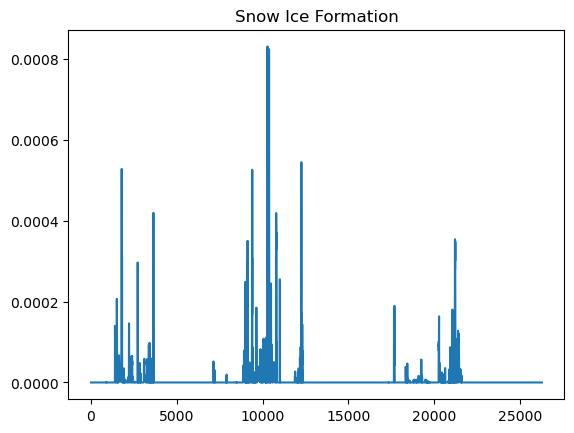

In [11]:
plt.plot(ds["snoice"])
plt.title("Snow Ice Formation")
plt.show()

## Tracers
From the run log:
```
 (icepack_write_tracer_indices):
   nt_Tsfc =            1
   nt_qice =            2
   nt_qsno =           10
   nt_sice =           13
   nt_alvl =           21
   nt_vlvl =           22
   nt_apnd =           23
   nt_hpnd =           24
   nt_ipnd =           25
```

In [12]:
#ds

Note that Fortran starts at 1, if we use `.sel` then the indicies will match. Also, trcrn is the variable and ntrcr is the dimension.

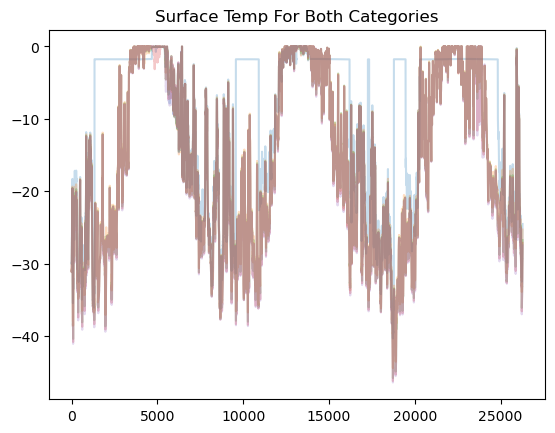

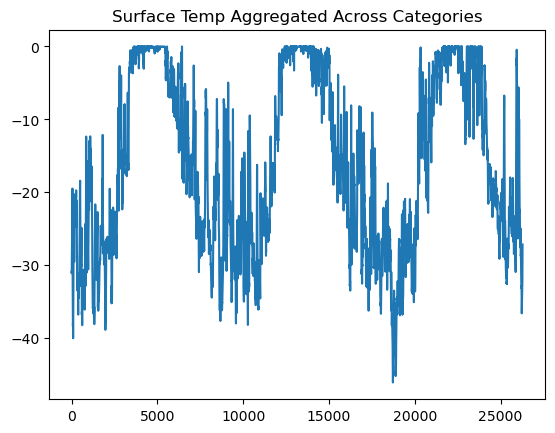

In [13]:
plt.plot(ds.sel(ntrcr=1)["trcrn"], alpha=.25)
plt.title("Surface Temp For Both Categories")
plt.show()
plt.plot(ds.sel(ntrcr=1)["trcr"])
plt.title("Surface Temp Aggregated Across Categories")
plt.show()

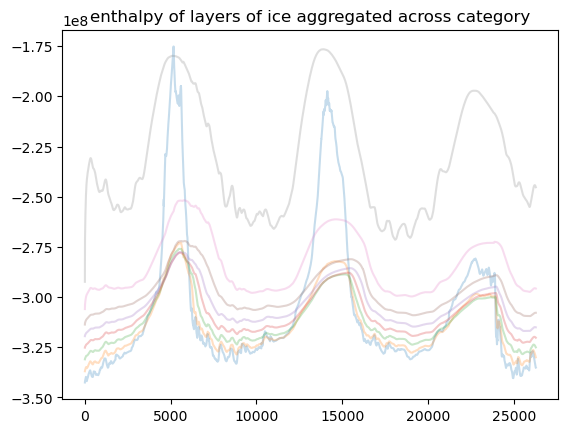

In [14]:
for i in range (2,10):
    plt.plot(ds.sel(ntrcr=i)["trcr"], alpha=.25)
plt.title("enthalpy of layers of ice aggregated across category")
plt.show()

Note that when we are training the model we will use the `trcrn` version of all of the variables, this is the pre-aggregated version (which provides no new info)

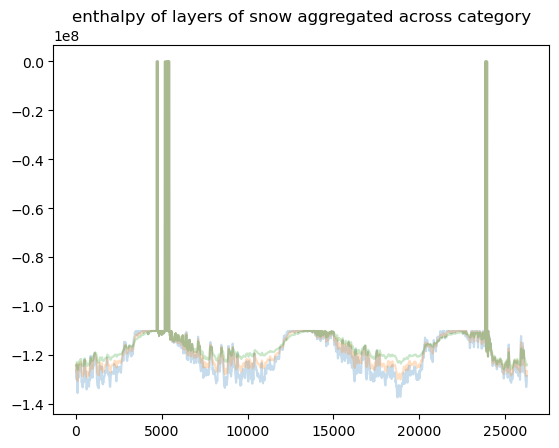

In [25]:
for i in range (10,13):
    plt.plot(ds.sel(ntrcr=i)["trcr"], alpha=.25)
plt.title("enthalpy of layers of snow aggregated across category")
plt.show()

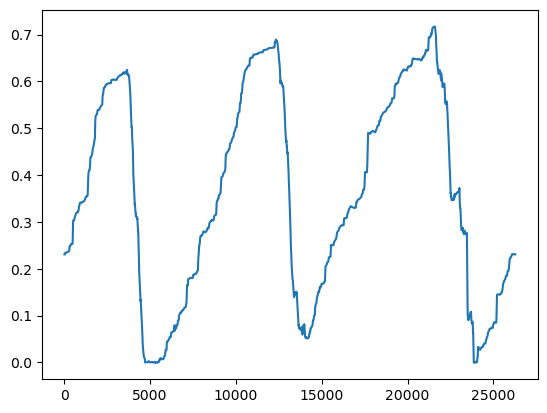

In [26]:
plt.plot(ds["vsno"])

Weird blip, ask and look at another run?

21
22


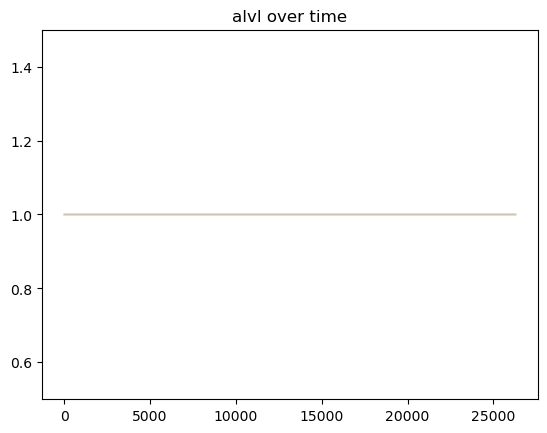

In [27]:
for i in range (21,23):
    plt.plot(ds.sel(ntrcr=i)["trcr"], alpha=.25)
    print(i)
plt.ylim(0.5,1.5)
plt.title("alvl over time")
plt.show()

In [18]:
print(ds.sel(ntrcr=21)["trcr"].max()-ds.sel(ntrcr=21)["trcr"].min())

<xarray.DataArray 'trcr' ()> Size: 8B
array(3.44169138e-15)
Coordinates:
    ni       int32 4B 3
    ntrcr    int32 4B 21


We would expect this to be 0, this is a ridging parameter.

## Dropped Variables

| Dropped Variable | Definition                | Notes|
|----------|---------------------------|------|
|aice     | area of ice (total)       | redundant|
|vice     | volume of ice (total)       | redundant|
|vsno     | volume of snow (total)       | redundant|
|trcr*    | Aggregated versions of trcrn*|redundant|
|uvel/vvel | x/y velocity of ice| drop, always 0 |
|divu | velocity divergence|drop, always 0 |
|shear | strain rate|drop, always 0 |
|strength| compressive ice strength| drop, always 0 |
|pnd_* |melt pond variables|out of scope?|
|last 3 tracers|melt pond variables|out of scope?|
|nt_alvl & nt_vlvl (tracer 21 & 22| level ice area/vol| out of scope?|

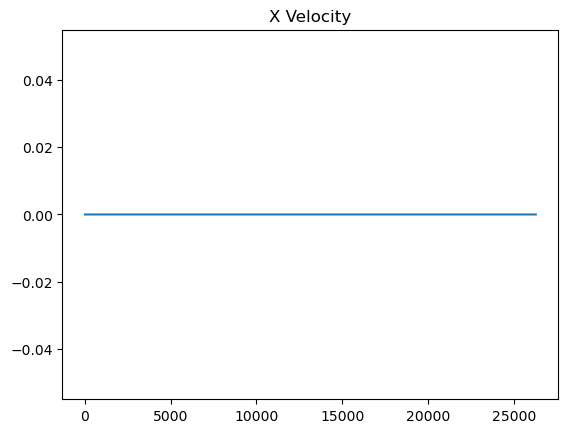

In [19]:
plt.plot(ds["uvel"])
plt.title("X Velocity")
plt.show()

We would expect this to be 0, this is a CICE parameter.

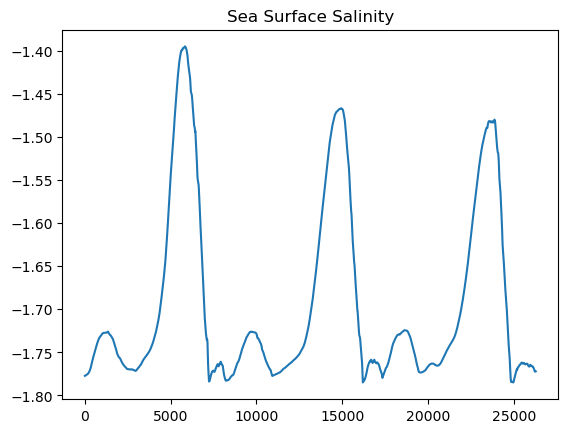

In [29]:
plt.plot(ds["sst"])
plt.title("Sea Surface Salinity")
plt.show()

We discussed a switch to fixed ocean forcing, the sss and qdp won't vary in that case.

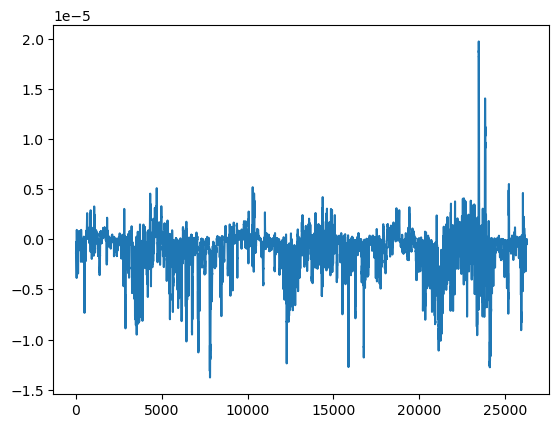

In [33]:
plt.plot(ds["evap"])

Keep Tracer Vars:
```
   nt_Tsfc =            1
   nt_qice =            2
   nt_qsno =           10
   nt_sice =           13
```

In [32]:
list(ds.data_vars)

['timestep',
 'date',
 'aice',
 'vice',
 'vsno',
 'uvel',
 'vvel',
 'divu',
 'shear',
 'strength',
 'evap',
 'fsnow',
 'frazil',
 'fswabs',
 'flw',
 'flwout',
 'fsens',
 'fsurf',
 'flat',
 'frain',
 'Tair',
 'Qa',
 'fsw',
 'fcondtop',
 'meltt',
 'meltb',
 'meltl',
 'snoice',
 'dsnow',
 'congel',
 'sst',
 'sss',
 'Tf',
 'fhocn',
 'melts',
 'apnd',
 'hpnd',
 'ipnd',
 'dpnd_flush',
 'dpnd_expon',
 'dpnd_freebd',
 'dpnd_initial',
 'dpnd_dlid',
 'dpnd_melt',
 'dpnd_ridge',
 'aicen',
 'vicen',
 'vsnon',
 'apndn',
 'hpndn',
 'ipndn',
 'dpnd_flushn',
 'dpnd_exponn',
 'dpnd_freebdn',
 'dpnd_initialn',
 'dpnd_dlidn',
 'trcr',
 'trcrn']